# 01 — Raw Sensor Quality Control

**Function:** Validate raw IMU and odometry logs before any preprocessing.

## Strategy

1. Load raw runs from `data/raw/`
2. Compute per-sensor QC statistics (sample rate, gaps, jitter, duration)
3. Plot sanity panels and dt-diagnostics for each sensor
4. Check accelerometer DC bias and saturation symptoms
5. Build a dataset-level pass/fail table and persist per-run artefacts

**Input:** raw text logs under `data/raw/{Main,Farm}/...`
**Output:** `reports/raw/` (per-run JSON + sanity PNG) and an in-memory pass/fail table.

---

## Setup


In [10]:
from pathlib import Path
import sys
import pandas as pd

# Make project root importable whether CWD is repo root or notebooks/
cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / 'src').exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.io import load_run, load_runs
from src.preprocess import (
    qc_report,
    plot_sanity,
    plot_dt_diagnostics,
    bias_from_first_seconds,
    time_range,
    sensor_channel_checks,
    save_qc_outputs,
    build_dataset_qc_table,
    split_qc_pass_fail,
)

## Single-run inspection

Pick one representative run and load its accelerometer, gyroscope, and odometry frames for detailed inspection.


In [11]:
# Select one run for detailed QC
RUN_DIR = PROJECT_ROOT / 'data' / 'raw' / 'Farm' / 'Run3'
run = load_run(RUN_DIR, include_pose=False)
acc, gyro, odo = run.acc, run.gyro, run.odo

print('Run:', run.run_id)
for name, df in [('acc', acc), ('gyro', gyro), ('odo', odo)]:
    print(f'{name}: n={len(df)}, t_rel=[{df.t_rel.min():.3f}, {df.t_rel.max():.3f}] s')

acc.head(), gyro.head(), odo.head()


Run: Run3
acc: n=67453, t_rel=[0.003, 809.429] s
gyro: n=67453, t_rel=[0.002, 809.429] s
odo: n=67453, t_rel=[0.000, 809.425] s


(              t      ax      ay      az   t_rel
 0  1.777374e+09  0.0851 -0.9941 -0.0674  0.0035
 1  1.777374e+09  0.0829 -0.9968 -0.0706  0.0145
 2  1.777374e+09  0.0857 -0.9959 -0.0670  0.0265
 3  1.777374e+09  0.0801 -0.9939 -0.0668  0.0394
 4  1.777374e+09  0.0791 -0.9983 -0.0708  0.0515,
               t      gx      gy      gz   t_rel
 0  1.777374e+09 -3.3201 -9.4276 -1.7553  0.0023
 1  1.777374e+09 -3.3380 -9.4581 -1.5705  0.0144
 2  1.777374e+09 -3.4343 -9.6107 -1.5647  0.0263
 3  1.777374e+09 -3.3538 -9.5801 -1.5116  0.0383
 4  1.777374e+09 -3.7096 -9.5496 -1.4805  0.0504,
               t   v1   v2   t_rel
 0  1.777374e+09 -0.0  0.0  0.0000
 1  1.777374e+09 -0.0  0.0  0.0111
 2  1.777374e+09 -0.0  0.0  0.0231
 3  1.777374e+09 -0.0  0.0  0.0351
 4  1.777374e+09 -0.0  0.0  0.0471)

### QC summary table

Per-sensor timing statistics: sample count, duration, median sample rate, dt percentiles, and gap counts.


In [12]:
# Single-run QC report table
single_run_qc = qc_report(run.sensors(), tcol='t_rel').set_index('sensor')
single_run_qc


,n,duration_s,fs_med_hz,dt_med,dt_p99,dt_max,gap_ratio_dtmax_over_dtmed,n_gaps_gt_factor_times_med
sensor,,,,,,,,
acc,67453,809.4252,83.332751,0.012,0.013,0.0208,1.733311,0
gyro,67453,809.4264,83.332751,0.012,0.013,0.0208,1.733311,0
odo,67453,809.4253,83.332751,0.012,0.013,0.0205,1.708317,0


### Sanity and dt diagnostics

Visual inspection of signal traces and time-step distributions to spot dropped samples or jitter.


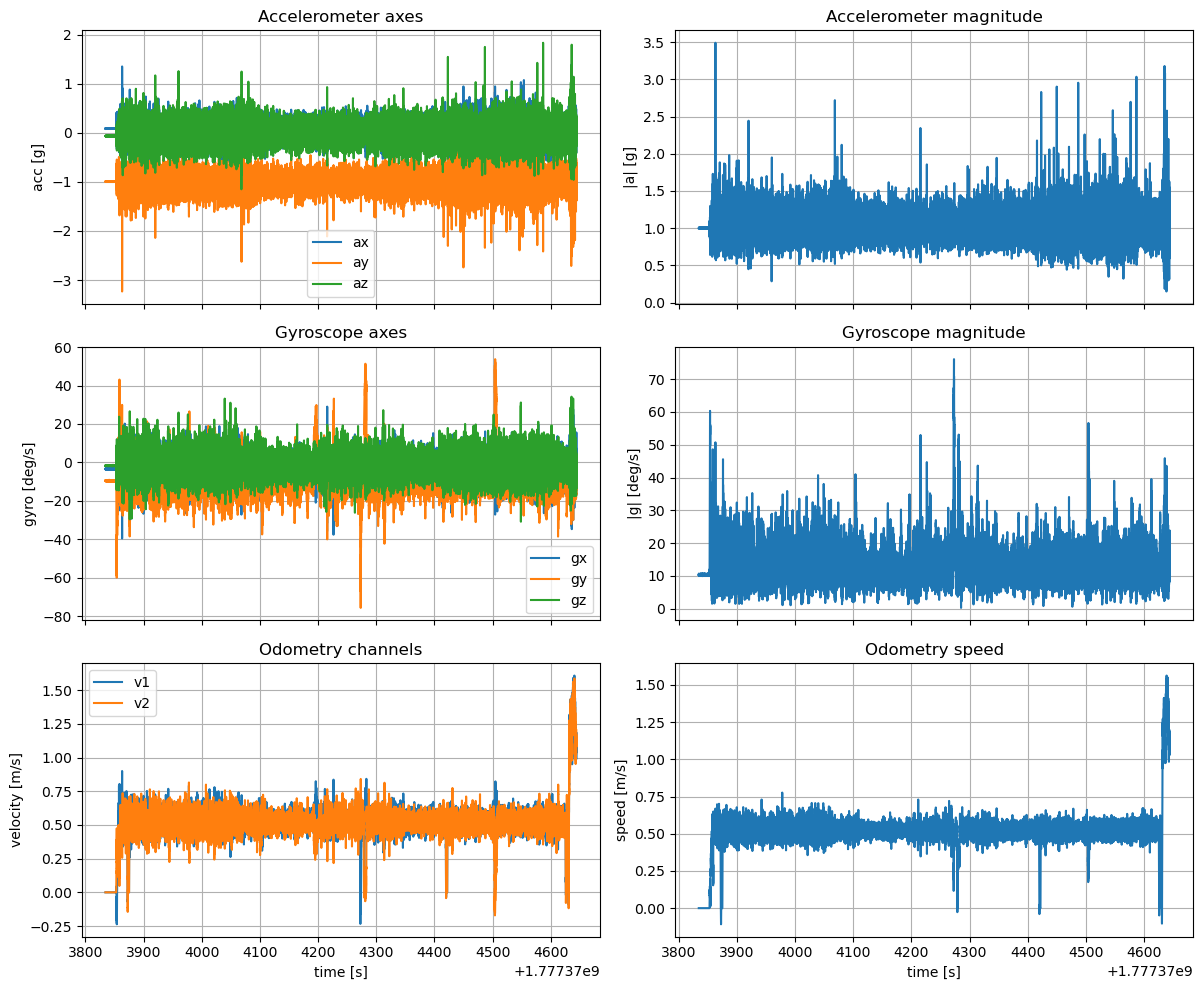

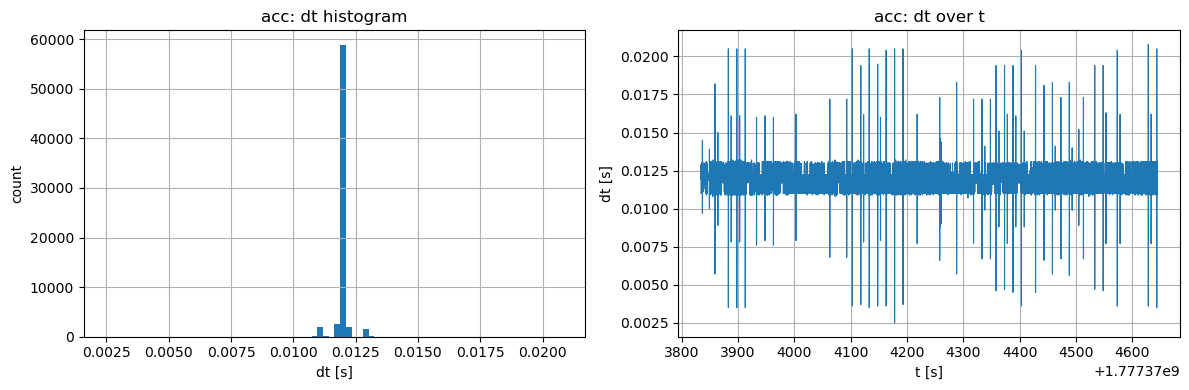

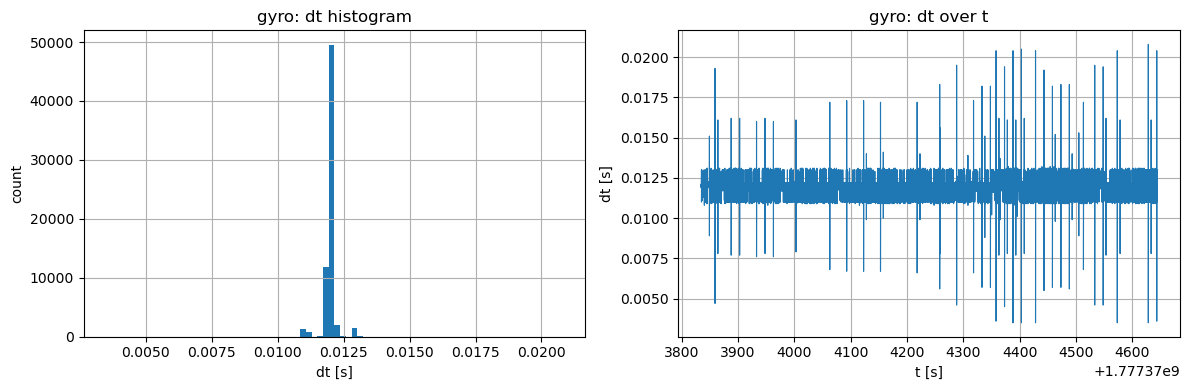

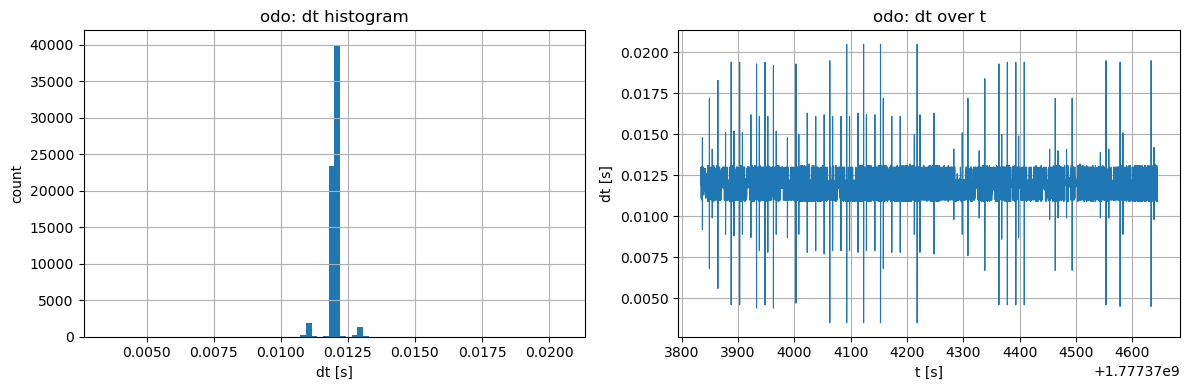

In [13]:
# Single-run sanity plots + dt diagnostics
plot_sanity(acc, gyro, odo, tcol='t', show=True)
for sensor_name, df in [('acc', acc), ('gyro', gyro), ('odo', odo)]:
    fig = plot_dt_diagnostics(sensor_name, df, tcol='t', bins=80, show=True)
    if fig is None:
        print(f'{sensor_name}: not enough samples for dt diagnostics')


### Bias and saturation checks

Estimate gyro/accelerometer DC bias from the first few seconds (robot stationary at run start) and flag potential clipping.


In [14]:
# Bias/time-range and sensor saturation checks
gyro_bias = bias_from_first_seconds(gyro, ['gx', 'gy', 'gz'], tcol='t_rel', seconds=5)
acc_bias = bias_from_first_seconds(acc, ['ax', 'ay', 'az'], tcol='t_rel', seconds=5)
acc_mag_median_5s = ((acc['ax']**2 + acc['ay']**2 + acc['az']**2) ** 0.5)[acc['t_rel'] <= 5].median()

print('Gyro bias (first 5s):')
print(gyro_bias)
print('\nAcc mean (first 5s):')
print(acc_bias)
print('\nAcc |a| median (first 5s):', float(acc_mag_median_5s) if pd.notna(acc_mag_median_5s) else float('nan'))

ranges = pd.DataFrame(
    {
        'sensor': ['acc', 'gyro', 'odo'],
        't_min': [time_range(acc)[0], time_range(gyro)[0], time_range(odo)[0]],
        't_max': [time_range(acc)[1], time_range(gyro)[1], time_range(odo)[1]],
    }
).set_index('sensor')
print('\nTime ranges (t_rel):')
ranges

range_sat_checks = pd.concat(
    [
        sensor_channel_checks(acc, ['ax', 'ay', 'az'], 'acc'),
        sensor_channel_checks(gyro, ['gx', 'gy', 'gz'], 'gyro'),
    ],
    ignore_index=True,
)
print('\nRange/saturation checks:')
range_sat_checks


Gyro bias (first 5s):
gx   -3.476763
gy   -9.558553
gz   -1.679215
dtype: float64

Acc mean (first 5s):
ax    0.083081
ay   -0.996660
az   -0.068685
dtype: float64

Acc |a| median (first 5s): 1.002432571298439

Time ranges (t_rel):

Range/saturation checks:


,sensor,channel,max_abs,n,n_unique,repeat_ratio,longest_constant_run,clip_candidate_count,flag_frozen,flag_flat_top
0,acc,ax,1.3861,67453,8555,0.000430,2,1,False,False
1,acc,ay,3.2332,67453,4269,0.001319,3,1,False,False
2,acc,az,1.8319,67453,9474,0.000326,2,1,False,False
3,gyro,gx,39.6491,67453,54719,0.000089,2,1,False,False
4,gyro,gy,75.7422,67453,2366,0.008258,3,1,False,False
5,gyro,gz,34.1865,67453,54964,0.000089,2,1,False,False


## Per-run artefact export

Persist QC tables and sanity plots under `reports/raw/`, mirroring the raw-dataset folder layout.


In [15]:
# Save QC artifacts per run (mirrors data/raw labels under reports/raw)
RAW_ROOT = PROJECT_ROOT / 'data' / 'raw'
MAIN_ROOT = RAW_ROOT/ 'Main'
FARM_ROOT = RAW_ROOT / 'Farm'
ARTIFACT_ROOT = PROJECT_ROOT / 'reports' / 'raw'
runs_for_artifacts = load_runs(MAIN_ROOT, include_pose=False)
runs_for_artifacts.append(load_run(FARM_ROOT / "Run1", include_pose=False))
runs_for_artifacts.append(load_run(FARM_ROOT / "Run2", include_pose=False))
runs_for_artifacts.append(load_run(FARM_ROOT / "Run3", include_pose=False))
runs_for_artifacts.append(load_run(FARM_ROOT / "Run4", include_pose=False))
runs_for_artifacts.append(load_run(FARM_ROOT / "Run5", include_pose=False))

save_qc_outputs(runs_for_artifacts, raw_root=RAW_ROOT, out_root=ARTIFACT_ROOT, tcol='t_rel')
print(f'Saved QC artifacts for {len(runs_for_artifacts)} runs to: {ARTIFACT_ROOT}')


Saved QC artifacts for 9 runs to: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/raw


## Dataset-level QC dashboard

Aggregate QC across all runs into one table and split into passing vs failing run lists used by downstream notebooks.


In [16]:
# Multi-run QC dashboard + pass/fail filtering
MAIN_ROOT = RAW_ROOT/ 'Main'
FARM_ROOT = RAW_ROOT / 'Farm'
runs = load_runs(MAIN_ROOT, include_pose=False)
runs.append(load_run(FARM_ROOT / "Run1", include_pose=False))
runs.append(load_run(FARM_ROOT / "Run2", include_pose=False))
runs.append(load_run(FARM_ROOT / "Run3", include_pose=False))
runs.append(load_run(FARM_ROOT / "Run4", include_pose=False))
runs.append(load_run(FARM_ROOT / "Run5", include_pose=False))


"""A run is good if pass_all == True. pass_all is true only if all are true:
- pass_dt_gaps: no large timestamp gaps in any sensor (n_gaps_gt_factor_times_med == 0), where large gap means dt > 5 * median_dt
- pass_duration: each sensor duration is at least min_duration_s (here we use 30s)
- pass_fs: median sample rate in expected range:
    - acc: 70-100 Hz
    - gyro: 70-100 Hz
    - odo: 80-130 Hz
"""
dataset_qc = build_dataset_qc_table(runs, tcol='t_rel', min_duration_s=30.0)
dataset_qc_good, dataset_qc_bad, good_run_ids, bad_run_ids = split_qc_pass_fail(dataset_qc)

print('Good runs:', len(good_run_ids))
print(good_run_ids)
print('Bad runs:', len(bad_run_ids))
print(bad_run_ids)

dataset_qc


Good runs: 9
['Run1', 'Run2', 'Run3', 'Run4', 'Run5', 'log_20260223_142511.490', 'log_20260226_102148.990', 'log_20260309_141435.414', 'log_20260326_120021.508']
Bad runs: 0
[]


,acc__n,acc__duration_s,acc__fs_med_hz,acc__dt_med,acc__dt_p99,acc__dt_max,acc__gap_ratio_dtmax_over_dtmed,acc__n_gaps_gt_factor_times_med,gyro__n,gyro__duration_s,...,odo__fs_med_hz,odo__dt_med,odo__dt_p99,odo__dt_max,odo__gap_ratio_dtmax_over_dtmed,odo__n_gaps_gt_factor_times_med,pass_dt_gaps,pass_duration,pass_fs,pass_all
run_id,,,,,,,,,,,,,,,,,,,,,
Run1,43488.0,522.0275,81.300717,0.0123,0.0128,0.0292,2.373987,0.0,43490.0,522.0277,...,81.300717,0.0123,0.0128,0.0273,2.219519,0.0,True,True,True,True
Run2,75007.0,900.3075,81.300717,0.0123,0.0128,0.0284,2.308936,0.0,75009.0,900.3192,...,81.300717,0.0123,0.0128,0.0284,2.308936,0.0,True,True,True,True
Run3,67453.0,809.4252,83.332751,0.0120,0.0130,0.0208,1.733311,0.0,67453.0,809.4264,...,83.332751,0.0120,0.0130,0.0205,1.708317,0.0,True,True,True,True
Run4,67250.0,806.9913,83.332751,0.0120,0.0130,0.0206,1.716661,0.0,67250.0,806.9901,...,83.332751,0.0120,0.0130,0.0205,1.708337,0.0,True,True,True,True
Run5,136192.0,1634.3000,83.332751,0.0120,0.0129,0.0206,1.716642,0.0,136192.0,1634.3000,...,83.332751,0.0120,0.0129,0.0207,1.724986,0.0,True,True,True,True
log_20260223_142511.490,243359.0,2920.4082,83.332751,0.0120,0.0130,0.0279,2.324982,0.0,243378.0,2920.6368,...,129.870696,0.0077,0.0088,0.0248,3.220801,0.0,True,True,True,True
log_20260226_102148.990,181067.0,2172.7994,83.332751,0.0120,0.0130,0.0177,1.474986,0.0,182779.0,2193.3403,...,129.870696,0.0077,0.0088,0.0164,2.129861,0.0,True,True,True,True
log_20260309_141435.414,299880.0,3598.7316,83.332751,0.0120,0.0130,0.0184,1.533319,0.0,299924.0,3599.2593,...,129.870696,0.0077,0.0088,0.0161,2.090940,0.0,True,True,True,True
log_20260326_120021.508,154168.0,1850.0146,83.332751,0.0120,0.0130,0.0181,1.508325,0.0,154117.0,1849.3997,...,129.870696,0.0077,0.0088,0.0149,1.935069,0.0,True,True,True,True
